In [1]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic info
print("Dataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Convert 'TotalCharges' to numeric (it may contain spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Add churn column as 1 or 0
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Basic churn rate
churn_rate = df['Churn'].mean()
print(f"\nChurn rate: {churn_rate:.2%}")

Dataset shape: (7043, 21)

Dataset preview:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stre

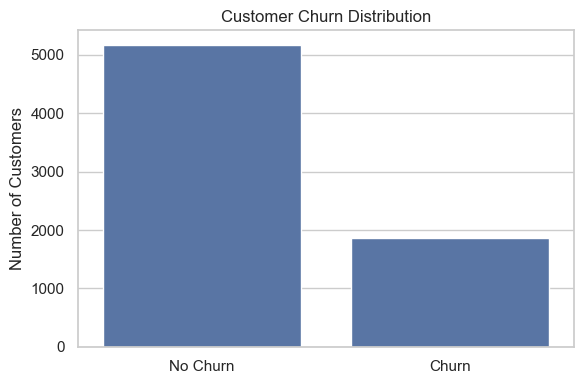

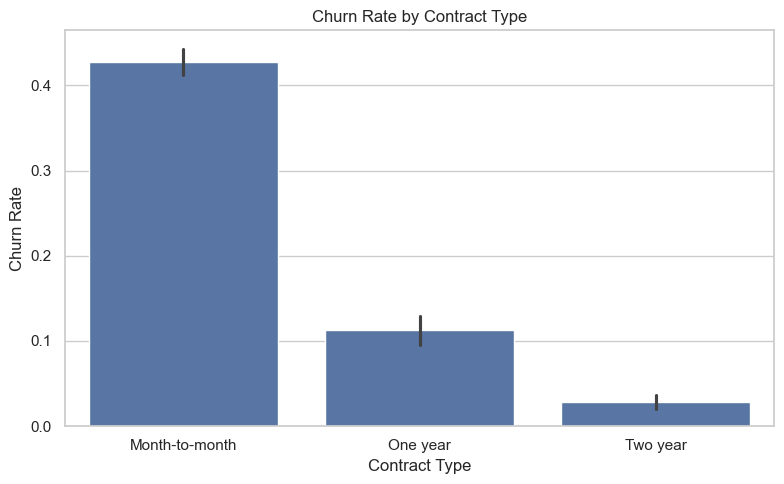

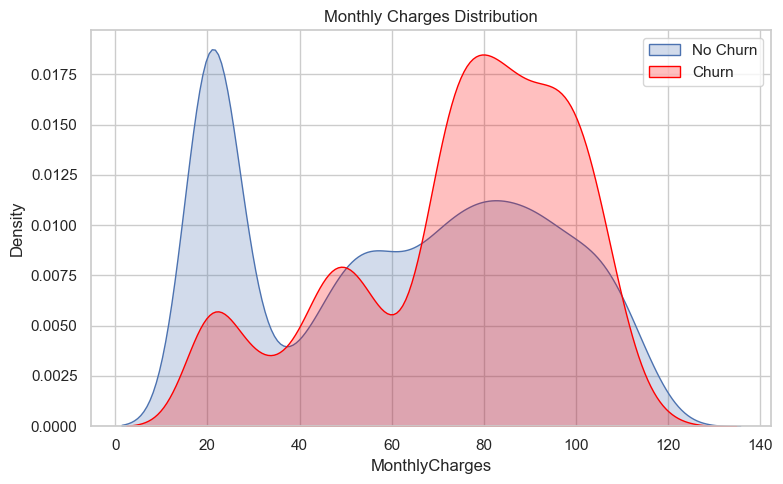

In [2]:
# Set seaborn style
sns.set(style="whitegrid")

# Plot distribution of churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.ylabel('Number of Customers')
plt.xlabel('')
plt.tight_layout()
plt.savefig('screenshots/churn_distribution.png', dpi=300)
plt.show()

# Compare churn rate by contract type
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Contract', y='Churn', estimator=lambda x: sum(x)/len(x))
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xlabel('Contract Type')
plt.tight_layout()
plt.savefig('screenshots/churn_by_contract.png', dpi=300)
plt.show()

# Monthly charges distribution by churn status
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['Churn'] == 0], x='MonthlyCharges', label='No Churn', fill=True)
sns.kdeplot(data=df[df['Churn'] == 1], x='MonthlyCharges', label='Churn', fill=True, color='red')
plt.title('Monthly Charges Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/monthly_charges_kde.png', dpi=300)
plt.show()